<a href="https://colab.research.google.com/github/emmanueloni570-hub/Oluwasegun_INFO4670_Fall2026-/blob/main/Copy_of_Assignment3_AssociationRuleMining_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv`

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–d)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt

## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook or update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing in Colab, the setup cell installs it.

In [ ]:
# Setup and load the dataset
try:
    from mlxtend.frequent_patterns import fpgrowth, association_rules
except ImportError:
    %pip -q install mlxtend networkx
    from mlxtend.frequent_patterns import fpgrowth, association_rules

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

DATA_PATH = "bread_basket.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Unique transactions:", df["transaction"].nunique())
print("Unique items:", df["item"].nunique())
df.head()

Dataset shape: (20507, 6)
Unique transactions: 9465
Unique items: 94


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–d) (30 pts)
### a) List variables and their dtypes (5 pts)

In [ ]:
# a) Variables and data types
print(df.dtypes)
print("\nVariables:")
for col in df.columns:
    print(f"- {col}: {df[col].dtype}")

transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object

Variables:
- transaction: int64
- item: object
- date_time: object
- time: object
- period_day: object
- weekday_weekend: object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand-in for Statistics.

In [ ]:
# b) Descriptive statistics
df.describe(include="all")

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

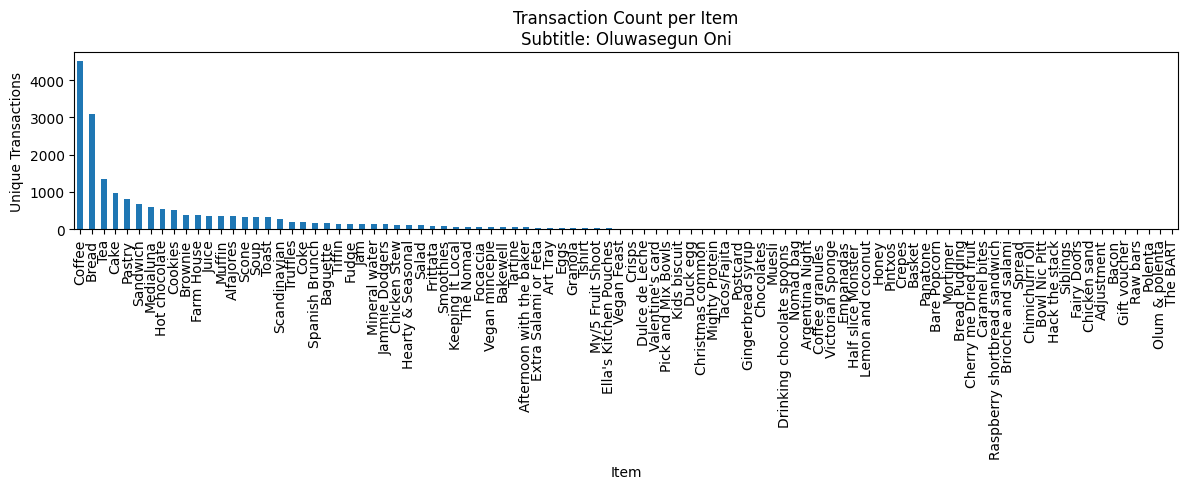

In [ ]:
# c) Bar plot of unique transaction counts per item
subtitle = "Oluwasegun Oni"
item_counts = df.groupby("item")["transaction"].nunique().sort_values(ascending=False)

ax = item_counts.plot(kind="bar", figsize=(12, 5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item")
plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [ ]:
# d) Required item counts
requested_items = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]
requested_counts = item_counts.reindex(requested_items).fillna(0).astype(int)
requested_counts.to_frame("unique_transaction_count")

,unique_transaction_count
item,
Coffee,4528
Tea,1350
Alfajores,344
Juice,365
Chicken Stew,123


## 3) Frequent Itemset Mining with FP-Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one-hot table (boolean), then run FP-Growth.

In [ ]:
# Create transaction × item boolean matrix
basket = (
    df.groupby(["transaction", "item"])["item"]
      .count()
      .unstack(fill_value=0)
      .astype(bool)
)

print("Basket shape:", basket.shape)

# FP-Growth with the required minimum support
frequent_itemsets = fpgrowth(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets.sort_values(
    ["itemset_size", "support"],
    ascending=[True, False]
).reset_index(drop=True)

print("Number of frequent itemsets:", len(frequent_itemsets))
frequent_itemsets

Basket shape: (9465, 94)
Number of frequent itemsets: 33


,support,itemsets,itemset_size
0,0.478394,(Coffee),1
1,0.327205,(Bread),1
2,0.142631,(Tea),1
3,0.103856,(Cake),1
4,0.086107,(Pastry),1
5,0.071844,(Sandwich),1
6,0.061807,(Medialuna),1
7,0.058320,(Hot chocolate),1
8,0.054411,(Cookies),1
9,0.040042,(Brownie),1


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, `min_threshold = 0.20`)

In [ ]:
# Generate association rules using confidence.
# A 0.20 threshold gives a concise, interpretable report table.
MIN_CONFIDENCE = 0.20

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)

report_table = rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].copy()

report_table = report_table.sort_values(
    ["confidence", "lift"],
    ascending=[False, False]
).reset_index(drop=True)

# Format itemsets for a cleaner report
report_table["antecedents"] = report_table["antecedents"].apply(
    lambda x: ", ".join(sorted(x))
)
report_table["consequents"] = report_table["consequents"].apply(
    lambda x: ", ".join(sorted(x))
)

print(f"Rules with confidence >= {MIN_CONFIDENCE}: {len(report_table)}")
report_table.round(4)

Rules with confidence >= 0.2: 13


,antecedents,consequents,support,confidence,lift
0,Toast,Coffee,0.0237,0.7044,1.4724
1,Medialuna,Coffee,0.0352,0.5692,1.1899
2,Pastry,Coffee,0.0475,0.5521,1.1542
3,Juice,Coffee,0.0206,0.5342,1.1167
4,Sandwich,Coffee,0.0382,0.5324,1.1128
5,Cake,Coffee,0.0547,0.5270,1.1015
6,Cookies,Coffee,0.0282,0.5184,1.0837
7,Hot chocolate,Coffee,0.0296,0.5072,1.0603
8,Tea,Coffee,0.0499,0.3496,0.7308
9,Pastry,Bread,0.0292,0.3387,1.0350


## 5) Rule Subgraph (Bread, Coffee, Cake, Tea)

The graph below uses the rules among these four items that meet the selected confidence threshold. Edge direction is antecedent → consequent, and edge width represents confidence.

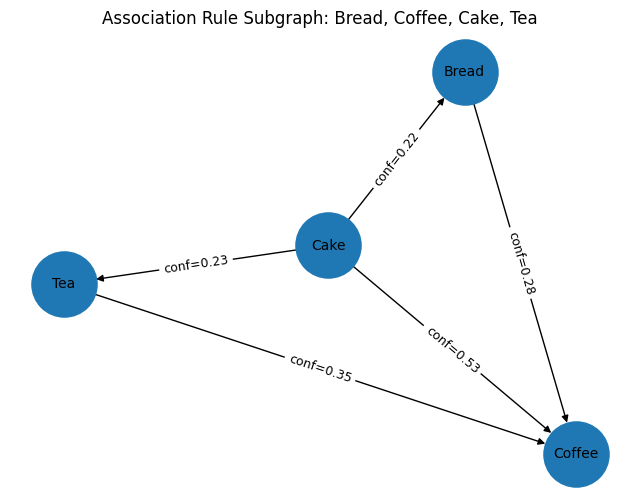

,antecedents,consequents,support,confidence,lift
0,(Bread),(Coffee),0.0900,0.2751,0.5751
1,(Cake),(Coffee),0.0547,0.5270,1.1015
2,(Tea),(Coffee),0.0499,0.3496,0.7308
9,(Cake),(Tea),0.0238,0.2289,1.6048
11,(Cake),(Bread),0.0233,0.2248,0.6871


In [ ]:
# Rule subgraph for Bread, Coffee, Cake, and Tea
focus_items = {"Bread", "Coffee", "Cake", "Tea"}

focus_rules = rules[
    rules["antecedents"].apply(lambda s: set(s).issubset(focus_items))
    & rules["consequents"].apply(lambda s: set(s).issubset(focus_items))
].copy()

G = nx.DiGraph()

for _, row in focus_rules.iterrows():
    antecedent = ", ".join(sorted(row["antecedents"]))
    consequent = ", ".join(sorted(row["consequents"]))
    if len(row["antecedents"]) == 1 and len(row["consequents"]) == 1:
        G.add_edge(
            antecedent,
            consequent,
            confidence=row["confidence"],
            lift=row["lift"]
        )

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_size=2200,
    arrows=True,
    font_size=10
)

edge_labels = {
    (u, v): f"conf={d['confidence']:.2f}"
    for u, v, d in G.edges(data=True)
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Association Rule Subgraph: Bread, Coffee, Cake, Tea")
plt.axis("off")
plt.show()

focus_rules[["antecedents", "consequents", "support", "confidence", "lift"]].round(4)

## 6) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:*

In [ ]:
# Calculate the requested Coffee + Cake -> Bread rule directly from the transactions.
# This rule's 3-item support is below the 0.02 FP-Growth threshold, so it is
# interpreted here directly rather than treated as one of the frequent itemsets.

baskets = df.groupby("transaction")["item"].apply(set)

coffee_cake = baskets.apply(lambda x: {"Coffee", "Cake"}.issubset(x))
coffee_cake_bread = baskets.apply(lambda x: {"Coffee", "Cake", "Bread"}.issubset(x))

support_ccb = coffee_cake_bread.mean()
confidence_ccb = coffee_cake_bread.sum() / coffee_cake.sum()

coffee_support = baskets.apply(lambda x: "Coffee" in x).mean()
cake_support = baskets.apply(lambda x: "Cake" in x).mean()
lift_ccb = confidence_ccb / coffee_support  # consequent = Bread? corrected below
bread_support = baskets.apply(lambda x: "Bread" in x).mean()
lift_ccb = confidence_ccb / bread_support

print(f"Support: {support_ccb:.4f} ({coffee_cake_bread.sum()} of {len(baskets)} transactions)")
print(f"Confidence: {confidence_ccb:.4f} ({coffee_cake_bread.sum()} of {coffee_cake.sum()} Coffee+Cake baskets)")
print(f"Lift: {lift_ccb:.4f}")

print(
    "\nInterpretation: About "
    f"{support_ccb:.2%} of all transactions contain Coffee, Cake, and Bread together. "
    f"Among transactions containing both Coffee and Cake, about {confidence_ccb:.2%} "
    "also contain Bread. The lift is below 1, so this combination does not show a "
    "positive association with Bread; Coffee and Cake together are actually less likely "
    "to contain Bread than would be expected from Bread's overall transaction rate."
)

Support: 0.0100 (95 of 9465 transactions)
Confidence: 0.1834 (95 of 518 Coffee+Cake baskets)
Lift: 0.5605

Interpretation: About 1.00% of all transactions contain Coffee, Cake, and Bread together. Among transactions containing both Coffee and Cake, about 18.34% also contain Bread. The lift is below 1, so this combination does not show a positive association with Bread; Coffee and Cake together are actually less likely to contain Bread than would be expected from Bread's overall transaction rate.
